In [3]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np


In [4]:
#Load the dataset
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()

In [5]:
print(train_images.shape)

(60000, 28, 28)


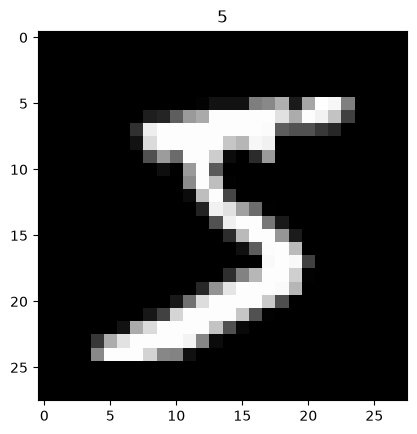

In [6]:
plt.imshow(train_images[0], cmap="gray")
plt.title(train_labels[0])
plt.show()

In [7]:
#Normalize
train_images = train_images.astype('float32') / 255
test_images = test_images.astype('float32') / 255

In [8]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

C:\Users\aashi\OneDrive\Desktop\khalti\venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [9]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [10]:
history = model.fit(
    train_images,
    train_labels,
    epochs=20,
    validation_data=(test_images, test_labels)
)

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9285 - loss: 0.2429 - val_accuracy: 0.9464 - val_loss: 0.1640
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9689 - loss: 0.1029 - val_accuracy: 0.9727 - val_loss: 0.0917
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9774 - loss: 0.0707 - val_accuracy: 0.9734 - val_loss: 0.0872
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9834 - loss: 0.0525 - val_accuracy: 0.9779 - val_loss: 0.0730
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9863 - loss: 0.0430 - val_accuracy: 0.9785 - val_loss: 0.0759
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9887 - loss: 0.0347 - val_accuracy: 0.9794 - val_loss: 0.0747
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9904 - loss: 0.0290 - val_accuracy: 0.9797 - val_loss: 0.0749
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9917 - loss: 0.0246 - 

In [11]:
test_loss, test_accuracy = model.evaluate(test_images, test_labels)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9796 - loss: 0.1284
Test Loss: 0.12841415405273438
Test Accuracy: 0.9796000123023987


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
[[9.7582006e-20 5.6519468e-12 1.5386977e-12 1.0000000e+00 2.0006779e-21
  3.4990739e-12 2.8536752e-21 5.0103365e-16 6.1388384e-13 8.1275861e-16]]
Predicted: 3
Actual: 3


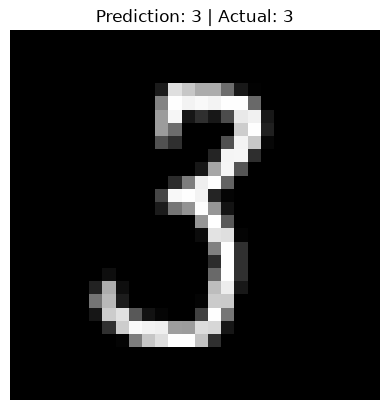

In [12]:
prediction = model.predict(test_images[231].reshape(1, 28, 28))
print(prediction)
predicted_digit = np.argmax(prediction)

print("Predicted:", predicted_digit)
print("Actual:", test_labels[231])
plt.imshow(test_images[231], cmap='gray')
plt.title(f"Prediction: {predicted_digit} | Actual: {test_labels[231]}")
plt.axis("off")
plt.show()


In [13]:
import tkinter as tk

root = tk.Tk()
root.title("Digit Recognizer")

canvas = tk.Canvas(root, width=280, height=280, bg="black")
canvas.pack()

def draw(event):
    x = event.x
    y = event.y

    canvas.create_oval(
        x-8,
        y-8,
        x+8,
        y+8,
        fill="white",
        outline="white"
    )

canvas.bind("<B1-Motion>", draw)

root.mainloop()

In [16]:
model.save("digit_model.keras")